# Signal and background definition

In [1]:
%load_ext autoreload
%autoreload 2

In [67]:
import numpy as np
from darklim.utils import get_cache_path
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import detprocess
from glob import glob
import pickle
import darklim
import scipy.stats as sps
from scipy.optimize import brentq
import yaml

In [38]:
from tes_2026_utils import *

In [33]:
get_cache_path("data/")

'/home/kmoraa/data/conda/envs/pytes2/lib/python3.10/site-packages/darklim/data'

In [5]:
constants = dict(
    #lee parameters:
    LEE_file = "data/Run57_LEE_templates/combined_spectra_shared57_CRESST_extrap.txt",
    LEE_improvement_PD = 1., # Per-volume improvement factor for the PD
    LEE_volume_scale_PD = 49 * 0.3 / 100, # Ratio of PD volume to Run 57 Si volume
    LEE_improvement_GaAs = 1., # Per-volume improvement factor for the GaAs
    LEE_volume_scale_GaAs = 49 * 0.5 / 100, # Ratio of GaAs volume to Run 57 Si volume
    #filter parameters
    filter_file = "data/filter_file.hdf5",
    template_channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight',
    base_energy_resolution = 0.3977,  # eV; this is the resolution of the 1x1 shared template from Run 57
    GaAs_energy_resolution = 0.156, #default in 2dfolf is 0.944
    PD_energy_resolution = 0.089, #default in simulate_2fold is 0.190
    E_th_PD = 1.,
    E_th_GaAs = 5.,
    E_max_PD = 20, #eV
    E_max_GaAs = 100, #eV
    ### simulation parameters:
    run_length_hours = 3,
    simulation_dir = "output_260220/",
    #parameters from simulate_2fold: 
    nsigma = 5, #sigma for t
    rate_Hz_GaAs = 50,  # Event rate in Hz (for the simulation--this should be as high as possible withou    t inducing pileup)
    rate_Hz_PD = 50,  # Event rate in Hz (for the simulation--this should be as high as possible without     inducing pileup)
    volume_cm3 = (225 * 4) / 1000 * 12,  #for LEE scaling.. 
    t_days = 300,
    sigma0 = 1e-37,
    target_mass_kg = 16.3e-3 #required 
    
)

In [26]:
with open("nominal_gaas_constants.yaml") as file:
    constants = yaml.safe_load(file)
constants

{'PD_energy_resolution': 0.089,
 'GaAs_energy_resolution': 0.156,
 'target_mass_kg': 0.00156,
 'E_max_GaAs': 100,
 'E_max_PD': 30,
 'E_th_GaAs': 5.0,
 'E_th_PD': 1.0,
 'LEE_file': 'data/Run57_LEE_templates/combined_spectra_shared57_CRESST_extrap.txt',
 'LEE_improvement_GaAs': 1.0,
 'LEE_improvement_PD': 1.0,
 'LEE_volume_scale_GaAs': 0.245,
 'LEE_volume_scale_PD': 0.147,
 'base_energy_resolution': 0.3977,
 'filter_file': 'data/filter_file.hdf5',
 'template_channel': 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight',
 'nsigma': 5,
 'rate_Hz_GaAs': 50,
 'rate_Hz_PD': 50,
 'run_length_hours': 0.5,
 'sigma0': 1e-37,
 'simulation_dir': 'output_260424/',
 't_days': 300,
 'volume_cm3': 10.8,
 'E_cutoff_PD': 0.85,
 'E_cutoff_GaAs': 10.0,
 'LEE_scale': 1.0,
 'collection_efficiency': 0.25}

In [7]:
#with open("test_file.yaml","w") as file:
#    yaml.dump(constants, file)

In [8]:
#with open("test_file.yaml") as file:
#    constants2 = yaml.safe_load(file)
#$constants2

In [9]:
template_OF, csd_OF, template_metadata = load_template(
    filter_file = constants["filter_file"],
    channel = constants["template_channel"],
    base_energy_resolution = constants["base_energy_resolution"],
    GaAs_energy_resolution=constants["GaAs_energy_resolution"],
    PD_energy_resolution=constants["PD_energy_resolution"],
    E_th_PD=constants["E_th_PD"],
    E_th_GaAs=constants["E_th_GaAs"],
)

INFO: Loading filter data from file /home/kmoraa/data/conda/envs/pytes2/lib/python3.10/site-packages/darklim/data/filter_file.hdf5


In [10]:
fs = template_metadata["sample_rate"]
pretrig = template_metadata["nb_pretrigger_samples"]

In [11]:
E0_full, E1_full, E2_full, sim_number_full, trigger_time_full, delta_delta_full, detected_full, n_runs = load_simulation(
    run_length_hours=constants["run_length_hours"],
    simulation_dir=constants["simulation_dir"],
    f_frequencies=fs,
    file_pattern = "my_simulation_2fold_*.pkl",

)

100%|██████████| 202/202 [03:06<00:00,  1.08it/s]


Loaded 202 runs of simulation results.


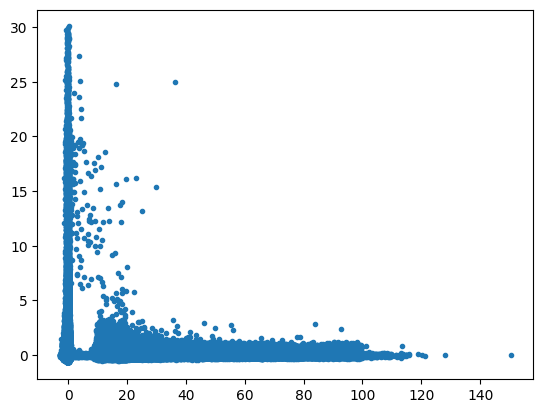

In [12]:
plt.clf()
plt.scatter(E0_full, E1_full, marker=".")
plt.show()

In [13]:
print_expectations(
    E0_full=E0_full, 
    E1_full=E1_full, 
    LEE_file = constants["LEE_file"],
    LEE_improvement_PD = constants["LEE_improvement_PD"],
    LEE_improvement_GaAs = constants["LEE_improvement_GaAs"],
    LEE_volume_scale_PD = constants["LEE_volume_scale_PD"],
    LEE_volume_scale_GaAs = constants["LEE_volume_scale_GaAs"],
    E_exposure_PD = constants["E_th_PD"],
    E_exposure_GaAs = constants["E_th_GaAs"],
    E_max_PD_keV=constants["E_max_PD"]*1e-3,
    E_max_GaAs_keV=constants["E_max_GaAs"]*1e-3,
    n_runs = n_runs,
)


Number of triggers observed in PD 1: 4922545
Expected rate of triggers in PD 1 above threshold: 4.40e+00 Hz
Effective exposure in PD: 310.71 hours (no volume scaling or LEE improvement)

Number of triggers observed in GaAs: 16806992
Expected rate of triggers in GaAs above threshold: 1.15e-02 Hz
Effective exposure in GaAs: 16969.48 days (no volume scaling or LEE improvement)

##########################

Effective exposure in PD after LEE and volume scaling: 2113.70 hours (10.46 hours per run)
Effective exposure in GaAs after LEE and volume scaling: 1662316.73 hours (8229.29 hours per run)


In [14]:
wimp_mass_MeVs = np.geomspace(1e-10, 1e-0,30)
lims = np.zeros(len(wimp_mass_MeVs))
for i, wimp_mass_MeV in enumerate(tqdm(wimp_mass_MeVs)):
    mu_bkg, mu_sig, fun = get_gaas_absorbtion_expectations(
    LEE_file = constants["LEE_file"], 
    nsigma = constants["nsigma"],
    baseline_res_eV=constants["base_energy_resolution"],
    volume_cm3=constants["volume_cm3"], 
    LEE_improvement=constants["LEE_improvement_GaAs"],
    t_days=constants["t_days"],
    sigma0=constants["sigma0"],
    target_mass_kg=constants["target_mass_kg"],
    wimp_mass_MeV = wimp_mass_MeV,
    )
    if np.isfinite(mu_sig):
        ul_mu_sig = counting_ul_sensitivity(mu_bkg)
        lims[i] = np.sqrt(ul_mu_sig / mu_sig) * constants["sigma0"]
    else:
        lims[i] = np.inf


  0%|          | 0/30 [00:00<?, ?it/s]

E_th_updated_keV, E_max_sig_keV
0.0019885 0.0012931000000000002
Mass 1.000e+02 meV is below threshold for detection. Skipping...
E_th_updated_keV, E_max_sig_keV
0.0019885 0.0014143216291070452
Mass 2.212e+02 meV is below threshold for detection. Skipping...
E_th_updated_keV, E_max_sig_keV
0.0019885 0.00168249009184775
Mass 4.894e+02 meV is below threshold for detection. Skipping...
E_th_updated_keV, E_max_sig_keV
0.0019885 0.0022757367338740566
 .... Loading files for GaAs
Loaded GaAs_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Tu, C. Kwei and C. Tung,Angular and energy dependences of the surface excitation parameter for semiconducting iii–v compounds, Surface Science601(2007) 865.
phonon ELF taken or calculated from H.M. Lawler and E.L. Shirley, Anharmonic effects on infrared spectra of GaAs and gap:  First-principles calculations, Phys. Rev. B70(2004) 245209 and E.D. Palik, Gallium arsenide (gaas), in Handbook of Optical Constants of Solids, E

 13%|█▎        | 4/30 [00:01<00:06,  3.94it/s]

Loaded /home/kmoraa/software/DarkELF/darkelf/../data/GaAs/GaAs_pDoS_anisotropic.dat for partial densities of states
GaAs_pDoS_anisotropic.dat
/home/kmoraa/software/DarkELF/darkelf/../data/GaAs/GaAs_Fn.npy
Warning! GaAs_Fn_anisotropic.npy does not exist! Need to calculate Fn(omega) from DoS. Use the function 'F_n_d_precompute' to produce these files 
E_th_updated_keV, E_max_sig_keV
0.0019885 0.0035881266199874907
 .... Loading files for GaAs
Loaded GaAs_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Tu, C. Kwei and C. Tung,Angular and energy dependences of the surface excitation parameter for semiconducting iii–v compounds, Surface Science601(2007) 865.
phonon ELF taken or calculated from H.M. Lawler and E.L. Shirley, Anharmonic effects on infrared spectra of GaAs and gap:  First-principles calculations, Phys. Rev. B70(2004) 245209 and E.D. Palik, Gallium arsenide (gaas), in Handbook of Optical Constants of Solids, E.D. Palik, ed.,pp. 429–443, Elsev

 17%|█▋        | 5/30 [00:01<00:10,  2.33it/s]

...

Loaded /home/kmoraa/software/DarkELF/darkelf/../data/GaAs/GaAs_pDoS_anisotropic.dat for partial densities of states
GaAs_pDoS_anisotropic.dat
/home/kmoraa/software/DarkELF/darkelf/../data/GaAs/GaAs_Fn.npy
Warning! GaAs_Fn_anisotropic.npy does not exist! Need to calculate Fn(omega) from DoS. Use the function 'F_n_d_precompute' to produce these files 
E_th_updated_keV, E_max_sig_keV
452035.36444292404 452035.36682912405
 .... Loading files for GaAs
Loaded GaAs_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Tu, C. Kwei and C. Tung,Angular and energy dependences of the surface excitation parameter for semiconducting iii–v compounds, Surface Science601(2007) 865.
phonon ELF taken or calculated from H.M. Lawler and E.L. Shirley, Anharmonic effects on infrared spectra of GaAs and gap:  First-principles calculations, Phys. Rev. B70(2004) 245209 and E.D. Palik, Gallium arsenide (gaas), in Handbook of Optical Constants of Solids, E.D. Palik, ed.,pp. 429–443,

 97%|█████████▋| 29/30 [00:24<00:00,  1.08it/s]

Loaded /home/kmoraa/software/DarkELF/darkelf/../data/GaAs/GaAs_pDoS_anisotropic.dat for partial densities of states
GaAs_pDoS_anisotropic.dat
/home/kmoraa/software/DarkELF/darkelf/../data/GaAs/GaAs_Fn.npy
Warning! GaAs_Fn_anisotropic.npy does not exist! Need to calculate Fn(omega) from DoS. Use the function 'F_n_d_precompute' to produce these files 
E_th_updated_keV, E_max_sig_keV
999999.9988069 1000000.0011931
 .... Loading files for GaAs
Loaded GaAs_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Tu, C. Kwei and C. Tung,Angular and energy dependences of the surface excitation parameter for semiconducting iii–v compounds, Surface Science601(2007) 865.
phonon ELF taken or calculated from H.M. Lawler and E.L. Shirley, Anharmonic effects on infrared spectra of GaAs and gap:  First-principles calculations, Phys. Rev. B70(2004) 245209 and E.D. Palik, Gallium arsenide (gaas), in Handbook of Optical Constants of Solids, E.D. Palik, ed.,pp. 429–443, Elsevi

100%|██████████| 30/30 [00:24<00:00,  1.20it/s]

Loaded /home/kmoraa/software/DarkELF/darkelf/../data/GaAs/GaAs_pDoS_anisotropic.dat for partial densities of states
GaAs_pDoS_anisotropic.dat
/home/kmoraa/software/DarkELF/darkelf/../data/GaAs/GaAs_Fn.npy
Warning! GaAs_Fn_anisotropic.npy does not exist! Need to calculate Fn(omega) from DoS. Use the function 'F_n_d_precompute' to produce these files 


In [15]:
ul_mu_sig

2.302585092994046

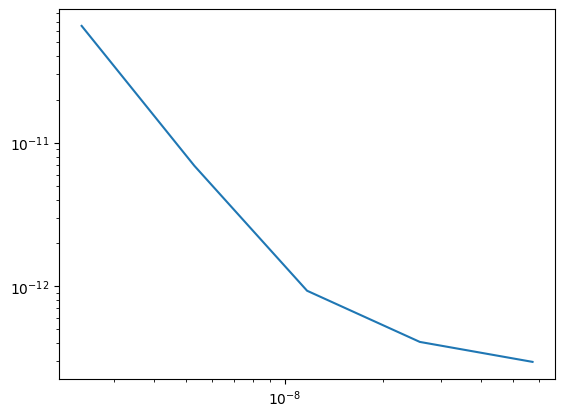

In [16]:
plt.clf()
plt.plot(wimp_mass_MeVs, lims)
plt.yscale("log")
plt.xscale("log")
plt.show()

In [17]:
ul_mu_sig = counting_ul_sensitivity(mu_bkg)

In [18]:
lim = np.sqrt(ul_mu_sig / mu_sig) * constants["sigma0"]
lim

inf

In [19]:
for k,i in constants.items():
    print(k,i)

PD_energy_resolution 0.089
GaAs_energy_resolution 0.156
target_mass_kg 0.00156
E_max_GaAs 100
E_max_PD 30
E_th_GaAs 5.0
E_th_PD 1.0
LEE_file data/Run57_LEE_templates/combined_spectra_shared57_CRESST_extrap.txt
LEE_improvement_GaAs 1.0
LEE_improvement_PD 1.0
LEE_volume_scale_GaAs 0.245
LEE_volume_scale_PD 0.147
base_energy_resolution 0.3977
filter_file data/filter_file.hdf5
template_channel Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight
nsigma 5
rate_Hz_GaAs 50
rate_Hz_PD 50
run_length_hours 0.5
sigma0 1e-37
simulation_dir output_260424/
t_days 300
volume_cm3 10.8
E_cutoff_PD 0.85
E_cutoff_GaAs 10.0
LEE_scale 1.0


In [76]:
eff_exposure_PD_hours, eff_exposure_GaAs_hours = get_effective_exposure(
    E0_full=E0_full, 
    E1_full = E1_full, 
    E_exposure_PD=constants["E_th_PD"],
    E_exposure_GaAs=constants["E_th_GaAs"],
    E_max_PD_keV=constants["E_max_PD"]*1e-3,
    E_max_GaAs_keV=constants["E_max_GaAs"]*1e-3,
    LEE_improvement_GaAs=constants["LEE_improvement_GaAs"],
    LEE_improvement_PD=constants["LEE_improvement_PD"],
    LEE_file=constants["LEE_file"],
    LEE_volume_scale_PD=constants["LEE_volume_scale_PD"],
    LEE_volume_scale_GaAs=constants["LEE_volume_scale_GaAs"],
    
)


Effective 1-fold exposure in GaAs: 69263.20 days
Effective 1-fold exposure in PD 1: 88.07 days
Effective 2-fold PD exposure: 1449521.40 days

Rates [1/day/module]:
2-fold in GaAs, with either PD: 3.23e-03
Number of coincident events: 4,743
hello
 .... Loading files for GaAs
Loaded GaAs_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Tu, C. Kwei and C. Tung,Angular and energy dependences of the surface excitation parameter for semiconducting iii–v compounds, Surface Science601(2007) 865.
phonon ELF taken or calculated from H.M. Lawler and E.L. Shirley, Anharmonic effects on infrared spectra of GaAs and gap:  First-principles calculations, Phys. Rev. B70(2004) 245209 and E.D. Palik, Gallium arsenide (gaas), in Handbook of Optical Constants of Solids, E.D. Palik, ed.,pp. 429–443, Elsevier (1985).
Loaded GaAs_epsphonon_data10K.dat for epsilon in phonon regime
Warning, GaAs_eps_electron_opticallimit.dat does not exist! dielectric function in optical limi

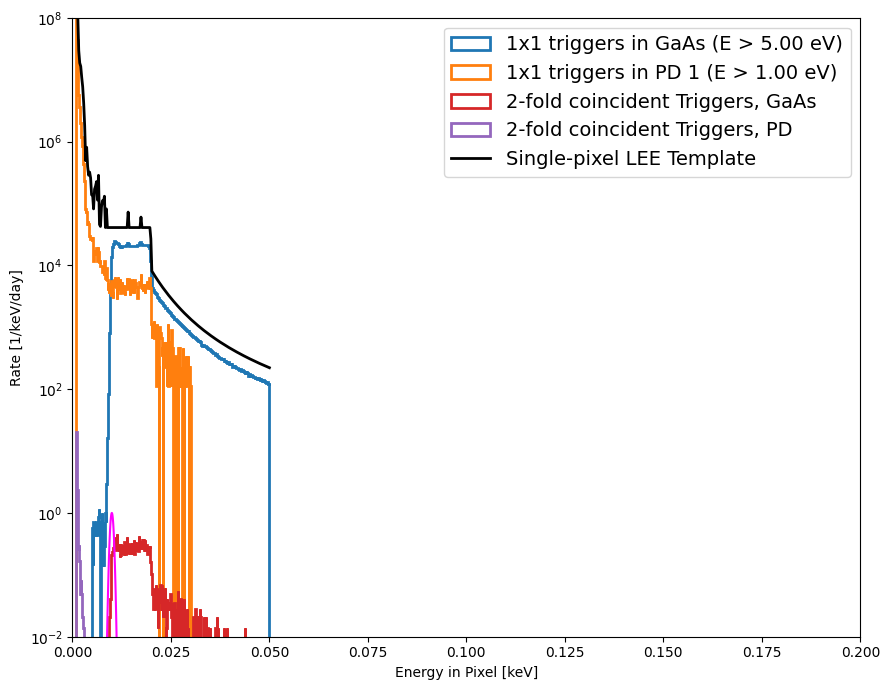

In [83]:
if True:
    plot_background_distribution(constants, E0_full, E1_full, delta_delta_full, eff_exposure_GaAs_hours,
                             eff_exposure_PD_hours, n_runs=n_runs,
                             run_length_hours = constants["run_length_hours"],
                             LEE_file = constants["LEE_file"],
                             LEE_improvement_GaAs=constants["LEE_improvement_GaAs"])

energies, signal_drde = get_gaas_signal(
    #m_DM_eV = 1e9,
    m_DM_eV = 10,
    sigma = constants["sigma0"],
    #mediator="massless",
    mediator="absorption",
    E_th_PD=constants["E_th_PD"]*1e-3,
    E_res_PD=constants["PD_energy_resolution"]*1e-3,
    E_th_GaAs=constants["E_th_GaAs"]*1e-3,
    E_res_GaAs=constants["GaAs_energy_resolution"]*1e-3,
    collection_efficiency=constants["collection_efficiency"],
    baseline_res_eV = constants["base_energy_resolution"]
)

signal_drde /= max(signal_drde)
plt.plot(energies, signal_drde, color="magenta")


plt.yscale("log")
#plt.xscale("log")
plt.xlim(0,0.2)
plt.show()

 .... Loading files for GaAs
Loaded GaAs_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Tu, C. Kwei and C. Tung,Angular and energy dependences of the surface excitation parameter for semiconducting iii–v compounds, Surface Science601(2007) 865.
phonon ELF taken or calculated from H.M. Lawler and E.L. Shirley, Anharmonic effects on infrared spectra of GaAs and gap:  First-principles calculations, Phys. Rev. B70(2004) 245209 and E.D. Palik, Gallium arsenide (gaas), in Handbook of Optical Constants of Solids, E.D. Palik, ed.,pp. 429–443, Elsevier (1985).
Loaded GaAs_epsphonon_data10K.dat for epsilon in phonon regime
Warning, GaAs_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Warning! Atomic Migdal calculation not present
Warning! Momentum dependent Zion for Migdal calculation not loaded. Using Z - number of valence electrons.
Loaded /home/kmoraa/sof

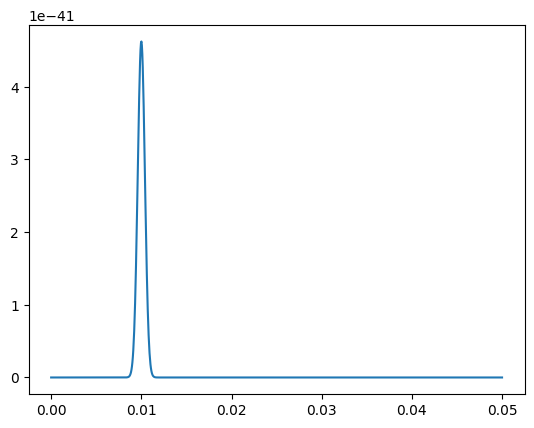

In [72]:
dRdE_signal_fun =  darklim.elf.get_dRdE_lambda_GaAs_absorption(
    mX_eV=10, kappa=constants["sigma0"], 
    res_eV=constants["base_energy_resolution"], 
    suppress_darkelf_output=False)
E_arr = np.linspace(0,0.05,1000)
dRdE_signal_arr = dRdE_signal_fun(E_arr)
plt.clf()
plt.plot(E_arr, dRdE_signal_arr)
plt.show()